In [1]:
# Instalar la última versión de ultralytics por si acaso
!pip install ultralytics

import ultralytics
from ultralytics import YOLO
print(f"✅ Ultralytics instalado correctamente. Versión: {ultralytics.__version__}")

✅ Ultralytics instalado correctamente. Versión: 8.4.60


In [2]:
# Cargamos los pesos base pre-entrenados de la arquitectura YOLOv11 Nano
model = YOLO('yolo11n.pt')
print("📦 Modelo YOLOv11 cargado en memoria y listo para entrenar.")

📦 Modelo YOLOv11 cargado en memoria y listo para entrenar.


In [3]:
# Iniciamos el entrenamiento con tu dataset limpio de Roboflow
results = model.train(
    data='data.yaml',       # Tu archivo de configuración local
    epochs=200,             # Probemos con 100 épocas. Si ves que mejora, puedes subirlo a 150.
    imgsz=640,              # Tamaño de imagen estándar
    batch=16,               # Si tu PC se congela o da error de memoria (OOM), bájalo a 8
    device=0,               # Usa 0 para GPU NVIDIA. Si no tienes gráfica dedicada, cambia a 'cpu'
    workers=2,
    save=True
)
print("🎉 ¡Entrenamiento completado!")

Ultralytics 8.4.60  Python-3.11.14 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspecti

In [4]:
# 1. Cargamos TU modelo ya entrenado
# Nota: Si es tu primer entrenamiento, la ruta será 'runs/detect/train/weights/best.pt'
# Si ya habías corrido otros, podría ser 'train2', 'train3', etc. Revisa tu carpeta 'runs'.
mi_modelo_optimizado = YOLO('runs/detect/train/weights/best.pt')

# 2. Hacemos la predicción subiendo el umbral de confianza a 0.5 o 0.6 para evitar falsos positivos
# Reemplaza "valid/images/tu_foto.jpg" por la ruta real de la imagen de las 2 vacas
resultados_prediccion = mi_modelo_optimizado.predict(
    source='valid/images/80_jpg.rf.7ffe2e3ab672f040b13bb1f368744003.jpg', 
    imgsz=1024,
    conf=0.55, 
    iou=0.45
)

# 3. Mostrar el conteo exacto en pantalla
for r in resultados_prediccion:
    conteo_vacas = len(r.boxes)
    print(f"\n🐄 ¡CONTEO REALIZADO! Se detectaron exactamente: {conteo_vacas} vacas.")


image 1/1 d:\2026\SIS421\IA_CODIGO\v2_Conteo_Reconocimiento_Ganado\valid\images\80_jpg.rf.7ffe2e3ab672f040b13bb1f368744003.jpg: 576x1024 14 Cows, 79.6ms
Speed: 6.9ms preprocess, 79.6ms inference, 4.2ms postprocess per image at shape (1, 3, 576, 1024)

🐄 ¡CONTEO REALIZADO! Se detectaron exactamente: 14 vacas.



image 1/1 d:\2026\SIS421\IA_CODIGO\v2_Conteo_Reconocimiento_Ganado\valid\images\80_jpg.rf.7ffe2e3ab672f040b13bb1f368744003.jpg: 576x1024 14 Cows, 83.4ms
Speed: 10.9ms preprocess, 83.4ms inference, 2.1ms postprocess per image at shape (1, 3, 576, 1024)


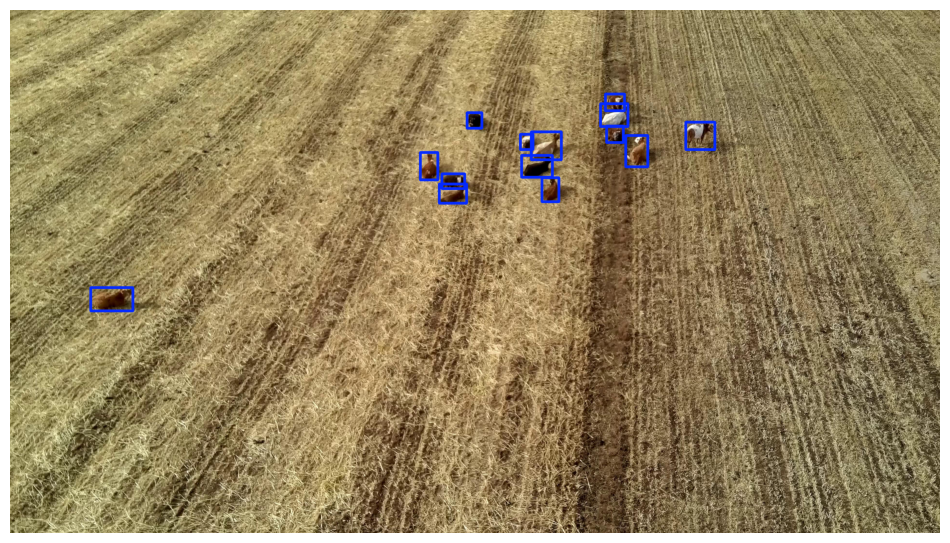

🐄 Conteo final: 14 vacas detectadas.


In [5]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt

# 1. Ejecutar la predicción en memoria
resultados_prediccion = mi_modelo_optimizado.predict(
    source='valid/images/80_jpg.rf.7ffe2e3ab672f040b13bb1f368744003.jpg', 
    imgsz=1024,
    conf=0.45, 
    iou=0.45
)

# 2. RENDERIZADO LIMPIO: Forzamos a YOLO a dibujar SOLO los cuadros
# 'labels=False' quita el nombre "Cow"
# 'conf=False' quita el porcentaje "0.95"
img_con_cuadros = resultados_prediccion[0].plot(labels=False, conf=False)

# 3. Convertir de BGR a RGB para Matplotlib
img_rgb = cv2.cvtColor(img_con_cuadros, cv2.COLOR_BGR2RGB)

# 4. Mostrar el resultado final en el Notebook
plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

# 5. Extra: Imprimir el conteo limpio abajo de la foto
print(f"🐄 Conteo final: {len(resultados_prediccion[0].boxes)} vacas detectadas.")

In [7]:
# Siguiente Celda: Conteo Ganado por Zona de Interés Estabilizada (Máximo Simultáneo - OPTIMIZADO)
import cv2
import os
from ultralytics import YOLO

# 1. Cargar modelo
ruta_modelo = "runs/detect/train/weights/best.pt"
if not os.path.exists(ruta_modelo):
    print(f"🚨 Error: No se encontraron los pesos en '{ruta_modelo}'.")
else:
    modelo_ganado = YOLO(ruta_modelo)
    print("✅ Modelo cargado con éxito.")

# 2. Rutas de video
video_entrada = "videos_dron/vuelo_ganado2.mp4" # Asegúrate de cambiar el nombre al video que quieras probar
video_salida = "resultados_procesados/ganado_zona1.mp4"
os.makedirs("resultados_procesados", exist_ok=True)

cap = cv2.VideoCapture(video_entrada)

if not cap.isOpened():
    print(f"⚠️ Alerta: No se pudo abrir el video.")
else:
    ancho = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    alto = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(video_salida, fourcc, fps, (ancho, alto))
    
    # === CONFIGURACIÓN DE LA ZONA DE CONTEO OPTIMIZADA ===
    # Reducimos el margen a solo el 2% para expandir la caja azul casi hasta el borde del video
    margen_x = int(ancho * 0.02)
    margen_y = int(alto * 0.02)
    
    zona_x1, zona_y1 = margen_x, margen_y
    zona_x2, zona_y2 = ancho - margen_x, alto - margen_y
    
    conteo_maximo_historico = 0
    
    print("🎬 Procesando video por Zona de Control Simultáneo...")
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        # Ajustamos conf a 0.58 para eliminar falsos positivos en la tierra/pasto
        resultados = modelo_ganado.track(
            frame, persist=True, device=0, 
            conf=0.58, iou=0.50, 
            tracker="bytetrack.yaml", imgsz=640, verbose=False
        )
        
        # Dibujar la Zona de Conteo (Cuadro Azul)
        cv2.rectangle(frame, (zona_x1, zona_y1), (zona_x2, zona_y2), (255, 0, 0), 3)
        cv2.putText(frame, "ZONA DE CONTROL DE GANADO", (zona_x1 + 10, zona_y1 - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
        
        vacas_en_este_frame = 0
        
        if resultados[0].boxes.id is not None:
            cajas = resultados[0].boxes.xyxy.cpu().numpy().astype(int)
            ids = resultados[0].boxes.id.cpu().numpy().astype(int)
            
            for box, id_vaca in zip(cajas, ids):
                x1, y1, x2, y2 = box
                
                # Calcular el centro de la vaca
                centro_x = int((x1 + x2) / 2)
                centro_y = int((y1 + y2) / 2)
                
                # EVALUAR SI EL CENTRO ESTÁ DENTRO DE LA ZONA AZUL
                if (zona_x1 <= centro_x <= zona_x2) and (zona_y1 <= centro_y <= zona_y2):
                    vacas_en_este_frame += 1
                    color = (0, 255, 0) # Verde si está adentro
                else:
                    color = (0, 165, 255) # Naranja si está fuera de la zona
                
                # Dibujar recuadros
                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                cv2.circle(frame, (centro_x, centro_y), 4, color, -1)
        
        # Guardar el pico más alto de vacas vistas juntas en la zona
        if vacas_en_este_frame > conteo_maximo_historico:
            conteo_maximo_historico = vacas_en_este_frame
            
        # Marcador en pantalla
        cv2.rectangle(frame, (20, 20), (380, 110), (0, 0, 0), -1)
        cv2.putText(frame, f"En la Zona Ahora: {vacas_en_este_frame}", (30, 55), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.putText(frame, f"Total Registrado: {conteo_maximo_historico}", (30, 95), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        
        out.write(frame)
        
    cap.release()
    out.release()
    
    print("--------------------------------------------------------------------------")
    print(f"🎉 ¡PROCESAMIENTO POR ZONA COMPLETADO!")
    print(f"📊 Cantidad máxima de ganado detectado simultáneamente: {conteo_maximo_historico}")
    print(f"📂 Archivo en: '{video_salida}'")
    print("--------------------------------------------------------------------------")

✅ Modelo cargado con éxito.
🎬 Procesando video por Zona de Control Simultáneo...
--------------------------------------------------------------------------
🎉 ¡PROCESAMIENTO POR ZONA COMPLETADO!
📊 Cantidad máxima de ganado detectado simultáneamente: 1
📂 Archivo en: 'resultados_procesados/ganado_zona1.mp4'
--------------------------------------------------------------------------


In [ ]:
# Siguiente Celda: Detección y Conteo de Ganado EN VIVO por Zona
import cv2
import os
from ultralytics import YOLO

# 1. Cargar tu modelo entrenado con los nuevos datos combinados
ruta_modelo = "runs/detect/train/weights/best.pt"
if not os.path.exists(ruta_modelo):
    print(f"🚨 Error: No se encontraron los pesos en '{ruta_modelo}'.")
else:
    modelo_ganado = YOLO(ruta_modelo)
    print("✅ Modelo cargado con éxito para transmisión EN VIVO.")

# 2. CONFIGURAR LA FUENTE DE VIDEO
# Usa 0 para la cámara web de tu laptop. 
# Si usas la app del celular, pon la URL que te dé la app entre comillas, ej: "http://192.168.1.50:8080/video"
url_camara = "http://192.168.0.105:8080/video"

cap = cv2.VideoCapture(url_camara)

if not cap.isOpened():
    print(f"⚠️ Alerta: No se pudo conectar a la cámara ({url_camara}).")
else:
    print("🎬 Transmisión iniciada. Presiona la tecla 'q' en tu teclado para cerrar la ventana.")
    
    # Obtener el tamaño de la transmisión para calcular la zona azul
    ancho = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    alto = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Definimos la zona azul (expandida al 2% como lo calibramos antes)
    margen_x = int(ancho * 0.02)
    margen_y = int(alto * 0.02)
    zona_x1, zona_y1 = margen_x, margen_y
    zona_x2, zona_y2 = ancho - margen_x, alto - margen_y
    
    conteo_maximo_historico = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            print("🚨 Se perdió la señal de la cámara.")
            break
            
        # Rastreo en tiempo real usando tu tarjeta RTX 2050
        # Bajamos un poco la resolución (imgsz=320 o 640) para garantizar que vaya fluido y sin retrasos
        resultados = modelo_ganado.track(
            frame, persist=True, device=0, 
            conf=0.58, iou=0.40, 
            tracker="bytetrack.yaml", imgsz=640, verbose=False
        )
        
        # Dibujar la Zona de Conteo Azul en la pantalla en vivo
        cv2.rectangle(frame, (zona_x1, zona_y1), (zona_x2, zona_y2), (255, 0, 0), 2)
        cv2.putText(frame, "ZONA DE CONTROL EN VIVO", (zona_x1 + 10, zona_y1 + 25), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
        
        vacas_en_este_instante = 0
        
        if resultados[0].boxes.id is not None:
            cajas = resultados[0].boxes.xyxy.cpu().numpy().astype(int)
            ids = resultados[0].boxes.id.cpu().numpy().astype(int)
            
            for box, id_vaca in zip(cajas, ids):
                x1, y1, x2, y2 = box
                centro_x = int((x1 + x2) / 2)
                centro_y = int((y1 + y2) / 2)
                
                # Evaluar si está dentro del cuadro azul
                if (zona_x1 <= centro_x <= zona_x2) and (zona_y1 <= centro_y <= zona_y2):
                    vacas_en_este_instante += 1
                    color = (0, 255, 0) # Verde
                else:
                    color = (0, 165, 255) # Naranja fuera de zona
                
                # Dibujar recuadros en la pantalla en vivo
                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                cv2.circle(frame, (centro_x, centro_y), 4, color, -1)
                cv2.putText(frame, f"ID: {id_vaca}", (x1, y1 - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        
        # Actualizar el pico más alto visto en vivo
        if vacas_en_este_instante > conteo_maximo_historico:
            conteo_maximo_historico = vacas_en_este_instante
            
        # Cuadro de texto flotante en la pantalla en vivo
        cv2.rectangle(frame, (20, 20), (380, 110), (0, 0, 0), -1)
        cv2.putText(frame, f"Vistas Ahora: {vacas_en_este_instante}", (30, 55), q
        cv2.putText(frame, f"Máximo Registrado: {conteo_maximo_historico}", (30, 95), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        
        # MOSTRAR LA VENTANA EN VIVO EN TU ESCRITORIO
        cv2.imshow("🛸 Monitoreo de Ganado con Dron - EN VIVO", frame)
        
        # DETENER TRANSMISIÓN: Si presionas la tecla 'q', la ventana se cierra
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
            
    cap.release()
    cv2.destroyAllWindows()
    print("🎬 Transmisión finalizada correctamente.")

✅ Modelo cargado con éxito para transmisión EN VIVO.
🎬 Transmisión iniciada. Presiona la tecla 'q' en tu teclado para cerrar la ventana.
🚨 Se perdió la señal de la cámara.
🎬 Transmisión finalizada correctamente.
